In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('height-weight.csv')

In [3]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0.5, 1.0, 'Height vs Weight')

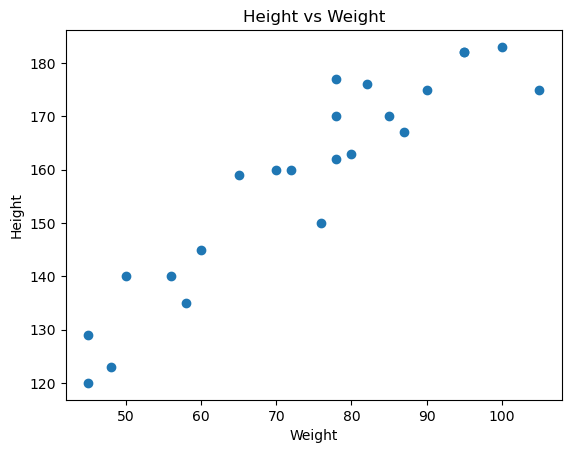

In [4]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.title('Height vs Weight')

### Correlation
 Correlation is a statistical measure that is used to determine the relationship between two variables.It is used to understand how changes in one variable are associated with changes into another variable

In [5]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


### Note
While training your data in linear regression, the independent feature X must always be in 2-D form while the dependent feature must be in 1-D format

### Why?
Independent features must be 2D because linear regression is defined as a matrix multiplication 𝑋𝑤, while the dependent variable is 1D since each input sample maps to exactly one scalar output.



In [6]:
#Create a Independent feature X
X=df[['Weight']]

In [7]:
X.shape

(23, 1)

In [8]:
#Create a Depenedant feature Y
Y=df['Height']

In [9]:
Y.shape

(23,)

In [10]:
#Split the data into Training Data and Testing Data
# Train Test Split
from sklearn.model_selection import train_test_split
X_Train,X_Test,Y_Train,Y_Test=train_test_split(X,Y,test_size=0.25,random_state=42)

In [ ]:
#Standardize the data
#Standardization 
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_Train=scaler.fit_transform(X_Train)
X_Test=scaler.transform(X_Test)

In [12]:
X_Train

array([[-0.87662801],
       [ 1.66773133],
       [ 0.33497168],
       [-1.48242785],
       [ 1.36483141],
       [-1.6641678 ],
       [-0.75546804],
       [-0.1496682 ],
       [ 0.21381171],
       [-1.36126788],
       [-0.99778797],
       [-0.02850823],
       [ 1.06193149],
       [ 0.57729161],
       [ 0.75903157],
       [ 0.88019153],
       [ 0.45613165]])

In [13]:
X_Test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [14]:
#Training the data
from sklearn.linear_model import LinearRegression
#n_jobs=-1 means using all processors. 
regression=LinearRegression(n_jobs=-1)
regression.fit(X_Train,Y_Train)


LinearRegression(n_jobs=-1)

In [15]:
print("Slope or Coefficient: ",regression.coef_)
print("Intercept: ",regression.intercept_)

Slope or Coefficient:  [17.2982057]
Intercept:  156.47058823529412


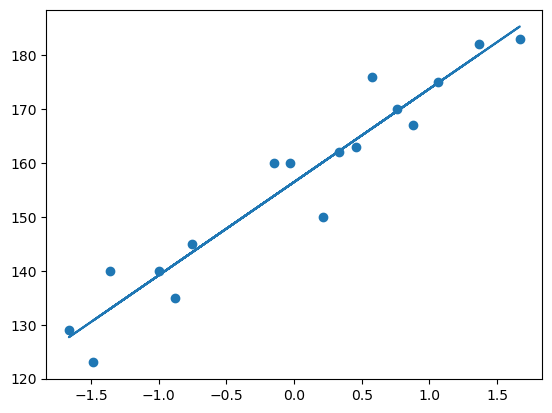

In [16]:
#plot training data plot best fit line
plt.scatter(X_Train,Y_Train)
plt.plot(X_Train,regression.predict(X_Train))

In [17]:
#prediction of the data 
Y_pred=regression.predict(X_Test)

In [18]:
#Performance measures
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse=mean_squared_error(Y_Test,Y_pred)
mae=mean_absolute_error(Y_Test,Y_pred)
rmse=np.sqrt(mse)
print("Mean Squared Error: ",mse)
print("Mean Absolute Error: ",mae)
print("Root Mean Squared Error: ",rmse)

Mean Squared Error:  114.84069295228699
Mean Absolute Error:  9.665125886795005
Root Mean Squared Error:  10.716374991212605


In [19]:
#Performance measure - R square
from sklearn.metrics import r2_score

In [21]:
score=r2_score(Y_Test,Y_pred)
print("Model accuracy: ",score*100)

Model accuracy:  73.60826717981276


In [25]:
X_Test.shape

(6, 1)

In [29]:
# Adjusted R2 
AdjR_Score=1 - (1-score)*(len(Y_Test)-1)/(len(Y_Test)-X_Test.shape[1]-1)
print(AdjR_Score)

0.6701033397476595


In [39]:
test_weight = scaler.transform(pd.DataFrame([[72]], columns=["Weight"]))
predicted_Ht = regression.predict(test_weight)
print("Predicted Height: ",predicted_Ht)

Predicted Height:  [155.97744705]


### OLS Regression

In [33]:
import statsmodels.api as sm


In [34]:
model=sm.OLS(Y_Train,X_Train).fit()

In [36]:
prediction=model.predict(X_Test)
print(prediction)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [38]:
model.summary()

c:\Users\Dell\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=17 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Sat, 07 Feb 2026   Prob (F-statistic):                       0.664
Time:                        13:19:03   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            17.2982     39.138      0.442      0.664     -65.671     100.267
==============================================================================
Omnibus:                        0.135   Durbin-Watson:                   0.002
Prob(Omnibus):                  0.935   Jarque-Bera (JB):                0.203
Skew:                          -0.166   Prob(JB):                        0.904
Kurtosis:                       2.581   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""